In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [2]:
def convolution2d(img, ker):
    new_img = np.zeros_like(img)

    k = ker.shape[0]

    pad_img = np.pad(img,(k//2,k//2),mode='constant', constant_values=0)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            new_img[i,j] = np.clip(np.sum(pad_img[i:i+k, j:j+k]*ker),0,255)
            # new_img[i,j] = np.sum(pad_img[i:i+k, j:j+k]*ker)

    return new_img

In [3]:
def mean_filter(img_path,filter_size = 3):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    mask = np.ones((filter_size,filter_size))/(filter_size**2)

    return convolution2d(img,mask).astype(np.uint8)

In [4]:
def median_filter(img_path,filter_size = 3):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
    new_img = np.zeros(img.shape)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            new_img[i][j] = np.median(img[i:i+filter_size, j:j+filter_size])
    return new_img.astype(np.uint8)

In [5]:
def prewitt_filter(img_path,filter_size = 3):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    ker = np.matmul(np.ones((filter_size,1)),np.arange(-(filter_size-1)//2 ,((filter_size-1)//2) + 1).reshape(1,filter_size))

    Gx = convolution2d(img,ker)
    Gy = convolution2d(img,ker.T)

    fltrd_img = Gx + Gy

    return fltrd_img.astype(np.uint8)

In [6]:
def laplacian_filter_4(img_path):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    ker = np.array([[0,1,0],[1,-4,1],[0,1,0]])

    return convolution2d(img,ker).astype(np.uint8)

In [7]:
def laplacian_filter_8(img_path,filter_size = 3):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    ker = np.ones((filter_size,filter_size))

    ker[filter_size//2][filter_size//2] = 1 - filter_size**2

    return convolution2d(img,ker).astype(np.uint8)

In [8]:
def sobel_filter(img_path):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    ker = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

    Gx = convolution2d(img,ker)
    Gy = convolution2d(img,ker.T)

    fltrd_img = Gx + Gy

    return fltrd_img.astype(np.uint8)

In [9]:
def sobel_filter_h(img_path):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    ker = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

    Gx = convolution2d(img,ker)

    fltrd_img = Gx

    return fltrd_img.astype(np.uint8)

In [10]:
def sobel_filter_v(img_path):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    ker = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

    Gy = convolution2d(img,ker.T)

    fltrd_img = Gy

    return fltrd_img.astype(np.uint8)

In [11]:
def sobel_filter_d(img_path):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    ker = np.array([[0,1,2],[-1,0,1], [-2,-1,0]])

    Gd = convolution2d(img,ker.T)

    fltrd_img = Gd

    return fltrd_img.astype(np.uint8)

In [12]:
def sobel_filter_ad(img_path):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    ker = np.array([[-2,-1,0],[-1,0,1],[0,1,2]])

    Gad = convolution2d(img,ker.T)

    fltrd_img = Gad

    return fltrd_img.astype(np.uint8)

In [13]:
def gen_gauss_kernel(ksize,sigma):
    ker = np.zeros((ksize,ksize))

    for i in range(-(ksize//2), ksize//2 + 1):
        for j in range(-(ksize//2), ksize//2 + 1):
            const = 1 / (2 * np.pi * sigma**2)
            exp = np.exp(-(i**2 + j**2) / (2 * sigma**2))
            ker[i+ksize//2, j+ksize//2] = const * exp

    return ker/np.sum(ker)

In [14]:
def gaussian_filter(img_path,filter_size = 3,sigma = None):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    if(sigma == None):
        sigma = 0.3*((filter_size-1)*0.5 - 1) + 0.8
        # sigma = (filter_size - 1)/6

    ker = gen_gauss_kernel(filter_size, sigma)

    fltrd_img = convolution2d(img,ker)

    return fltrd_img.astype(np.uint8)

In [15]:
def gen_lap_of_gauss_kernel(ksize,sigma):
    ker = np.zeros((ksize,ksize))

    for i in range(-(ksize//2), ksize//2 + 1):
        for j in range(-(ksize//2), ksize//2 + 1):
            const = -1 / (np.pi * sigma**4)
            fact = 1 - ((i**2 + j**2)/(2* sigma**2))
            exp = np.exp(-(i**2 + j**2) / (2 * sigma**2))
            ker[i+ksize//2, j+ksize//2] = const * fact *exp

    return ker/np.sum(ker)

In [16]:
def lap_of_gauss_filter(img_path,filter_size = 3, sigma = None):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    if(sigma == None):
        # sigma = 0.3*((filter_size-1)*0.5 - 1) + 0.
        sigma = (filter_size - 1)/6

    ker = gen_lap_of_gauss_kernel(filter_size, sigma)

    fltrd_img = convolution2d(img,ker)

    return fltrd_img.astype(np.uint8)

In [17]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import os

In [18]:
def files(path):
    for file in os.listdir(path):
        if os.path.isfile(os.path.join(path, file)):
            yield file

In [19]:
def filter(img_path):
    fltrd_imgs = {}
    fltrd_imgs["original"] = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
    fltrd_imgs["sobel"] = sobel_filter(img_path)
    fltrd_imgs["sobel_h"] = sobel_filter_h(img_path)
    fltrd_imgs["sobel_v"] = sobel_filter_v(img_path)
    fltrd_imgs["sobel_d"] = sobel_filter_d(img_path)
    fltrd_imgs["sobel_ad"] = sobel_filter_ad(img_path)
    fltrd_imgs["prewitt"] = prewitt_filter(img_path)
    fltrd_imgs["laplacian_4"] = laplacian_filter_4(img_path)
    fltrd_imgs["laplacian_8"] = laplacian_filter_8(img_path)

    for k in range(3,12,2):
        fltrd_imgs["mean_{}".format(k)] = mean_filter(img_path,k)
        fltrd_imgs["median_{}".format(k)] = median_filter(img_path,k)
        fltrd_imgs["gauss_{}".format(k)] = gaussian_filter(img_path,k)
        fltrd_imgs["lap_of_gauss_{}".format(k)] = lap_of_gauss_filter(img_path,k)
    return fltrd_imgs

In [20]:
filter_types =  ["original","sobel","sobel_h","sobel_v","sobel_d","sobel_ad","prewitt","laplacian_4","laplacian_8","mean","median","gauss","lap_of_gauss"]

In [21]:
img_widget = widgets.Dropdown(options= sorted(list(files("./"))))

In [22]:
def view(img_path,filter_type,filter_size):
    def on_value_change(change):
        view.fltrd_imgs = filter(img_path)

    img_widget.observe(on_value_change, names='value')

    if filter_type in ["original","sobel","sobel_h","sobel_v","sobel_d","sobel_ad","prewitt","laplacian_4","laplacian_8"]:
        cv2_imshow(view.fltrd_imgs[filter_type])
    else:
        cv2_imshow(view.fltrd_imgs["{}_{}".format(filter_type,filter_size)])

view.fltrd_imgs = filter("Cameraman_Salt&Pepper_0.005.jpg")

In [23]:
interact(view,img_path = img_widget,filter_type = filter_types,filter_size = [3,5,7,9,11])

interactive(children=(Dropdown(description='img_path', options=('Cameraman_Salt&Pepper_0.005.jpg', 'Cameraman_…

<function __main__.view(img_path, filter_type, filter_size)>

# Q2

In [24]:
def gaussian_unblur(img_path,sigma):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
    I0 = gaussian_filter(img_path,filter_size = 3,sigma = sigma)

    Ik = I0.copy()

    ker = gen_gauss_kernel(3,sigma)

    max_iter = 20

    for k in range(max_iter):
        Ak = convolution2d(Ik,ker)
        Ak = np.clip(Ak,1e-10,None)
        Bk = np.divide(I0,Ak)
        Ck = convolution2d(Bk,ker)
        Ik_1 = np.multiply(Ik,Ck)

        dis = np.linalg.norm(Ik_1-Ik)

        if(dis <= 1e-3):
            print("Converged after {} iterations".format(k+1))
            return (Ik_1)
            break
        Ik = Ik_1

    return (Ik)

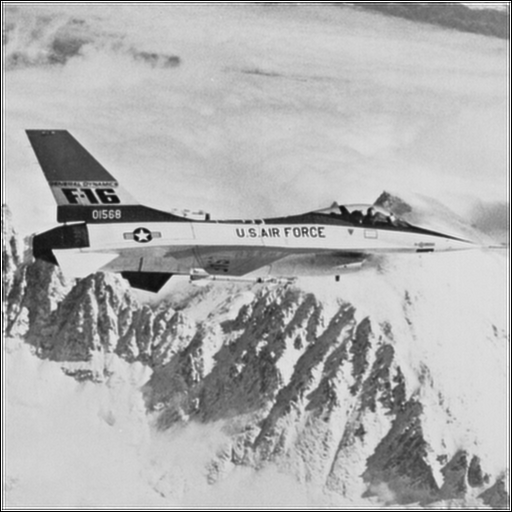

In [25]:
cv2_imshow(gaussian_unblur("jetplane.jpg",1))